# Boston Housing Price Prediction with Linear Regression

## Portfolio Project

This project builds an end-to-end **Linear Regression** workflow using the historical Boston Housing dataset.  
The goal is not only to train a model, but to show the full reasoning process behind a regression project:

- understand the problem and the data,
- inspect data quality,
- explore relationships,
- handle missing values without data leakage,
- train an interpretable baseline model,
- evaluate it with appropriate regression metrics,
- check important regression assumptions,
- and explain the model's limitations.

> **Portfolio note:** The notebook is written as a clean, readable project that can be used on GitHub and adapted for Kaggle.


## 1. Project Overview

The task is to predict **MEDV**, the median value of owner-occupied homes in Boston-area towns, using 13 input features.

This is a **supervised regression** problem because:

- the target is known during training,
- the target is numeric and continuous,
- and the goal is to estimate a value rather than assign a class.

I use **Linear Regression** as the baseline because it is simple, interpretable, and a useful first model for understanding how the predictors relate to the target.


## 2. Problem Statement

A useful regression model should do more than produce predictions. It should also help answer questions such as:

- Which variables are most strongly related to house values?
- How much prediction error does the baseline model make?
- Are the residuals consistent with the assumptions of linear regression?
- Does model performance remain reasonably stable across different train/validation splits?

The objective of this notebook is therefore to build a transparent baseline and evaluate both its **predictive performance** and its **statistical behavior**.


## 3. Dataset

The project notes describe the data as records for Boston suburbs or towns drawn from the **Boston Standard Metropolitan Statistical Area (SMSA) in 1970**, with feature definitions based on the UCI Machine Learning Repository.

### Feature Dictionary

| Feature | Description |
|---|---|
| `CRIM` | Per-capita crime rate by town |
| `ZN` | Proportion of residential land zoned for lots over 25,000 sq. ft. |
| `INDUS` | Proportion of non-retail business acres per town |
| `CHAS` | Charles River dummy variable (1 if tract bounds river, otherwise 0) |
| `NOX` | Nitric oxides concentration |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built before 1940 |
| `DIS` | Weighted distance to five Boston employment centers |
| `RAD` | Index of accessibility to radial highways |
| `TAX` | Full-value property-tax rate per $10,000 |
| `PTRATIO` | Pupil-teacher ratio by town |
| `B` | Historical race-derived variable included in the original dataset documentation |
| `LSTAT` | Percentage of lower-status population |
| `MEDV` | Median value of owner-occupied homes in $1,000s |

### Responsible-use note

This is a **historical educational dataset**. One feature (`B`) is explicitly race-derived in the original documentation, and the data itself comes from 1970. For that reason, this notebook should be treated as a learning exercise in regression—not as a model for current housing, lending, valuation, or policy decisions.


## 4. Import Libraries

The imports are kept focused on what this project actually uses: data manipulation, visualization, preprocessing, model training, cross-validation, and statistical diagnostics.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
np.random.seed(42)


# Portfolio visual style
portfolio_palette = ['#4C72B0', '#55A868']
sns.set_palette(portfolio_palette)

# Diverging colormap for correlation:
# negative = blue, near zero = neutral, positive = green
corr_cmap = LinearSegmentedColormap.from_list(
    "portfolio_corr",
    [portfolio_palette[0], "#F7F7F7", portfolio_palette[1]]
)

## 5. Load the Dataset

The loader checks two common locations:

1. the same folder as the notebook, and  
2. a `data/` folder one level above the notebook.

This makes the notebook easier to reuse locally and inside a GitHub repository without hard-coding a personal computer path.


In [2]:
candidate_paths = [
    Path("HousingData.csv"),
    Path("../data/HousingData.csv"),
]

# Kaggle environment
kaggle_input = Path("/kaggle/input")

if kaggle_input.exists():
    candidate_paths.extend(
        kaggle_input.glob("**/HousingData.csv")
    )

data_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "HousingData.csv was not found. "
        "Place it in the project data folder or attach the dataset in Kaggle."
    )

print(f"Dataset loaded from: {data_path}")

df = pd.read_csv(data_path)

df.head()

Dataset loaded from: ..\data\HousingData.csv


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## 6. Initial Data Validation

Before modeling, I check:

- dataset shape,
- column names,
- data types,
- duplicate rows,
- missing values,
- and descriptive statistics.

This step is important because modeling decisions should be based on the actual condition of the data, not assumptions about it.


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values by column:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDataset information:")
df.info()


Dataset shape: (506, 14)

Columns:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Duplicate rows: 0

Missing values by column:


,missing_values
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.611874,8.720192,0.00632,0.081900,0.253715,3.560263,88.9762
ZN,486.0,11.211934,23.388876,0.00000,0.000000,0.000000,12.500000,100.0000
INDUS,486.0,11.083992,6.835896,0.46000,5.190000,9.690000,18.100000,27.7400
CHAS,486.0,0.069959,0.255340,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,486.0,68.518519,27.999513,2.90000,45.175000,76.800000,93.975000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


### Data-quality findings

The dataset contains **506 observations and 14 columns**. There are no duplicate rows, but several predictors contain missing values.

I do **not** fill those missing values globally at this stage. Imputation will be learned from the training data inside a scikit-learn `Pipeline`, which helps prevent **data leakage**.


In [5]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_values")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_values"] / len(df) * 100
).round(2)

missing_summary

,missing_values,missing_percent
CRIM,20,3.95
ZN,20,3.95
INDUS,20,3.95
CHAS,20,3.95
AGE,20,3.95
LSTAT,20,3.95
NOX,0,0.00
RM,0,0.00
DIS,0,0.00
RAD,0,0.00


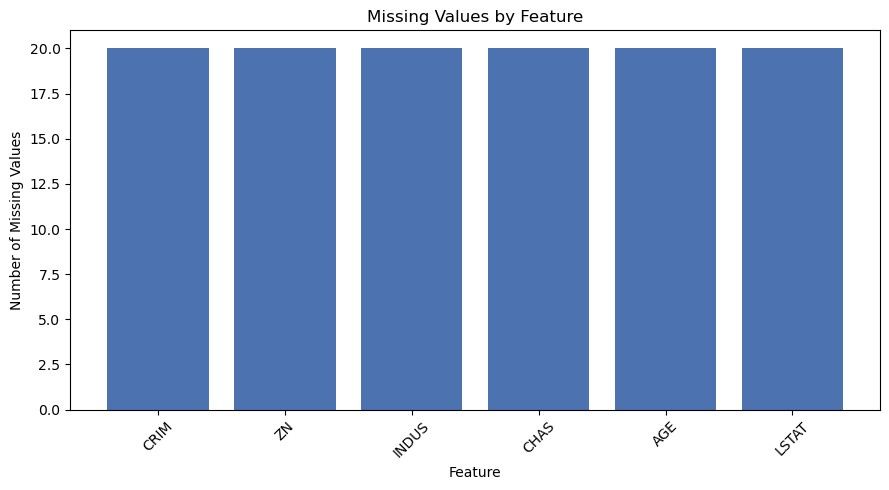

In [6]:
missing_to_plot = missing_summary[missing_summary["missing_values"] > 0]

plt.figure(figsize=(9, 5))
plt.bar(missing_to_plot.index, missing_to_plot["missing_values"], color=portfolio_palette[0])
plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Exploratory Data Analysis (EDA)

EDA helps me understand the target distribution and the relationships between predictors and `MEDV`.

The goal here is **not** to manipulate the data until it looks ideal. It is to learn what the dataset is telling us before training the model.


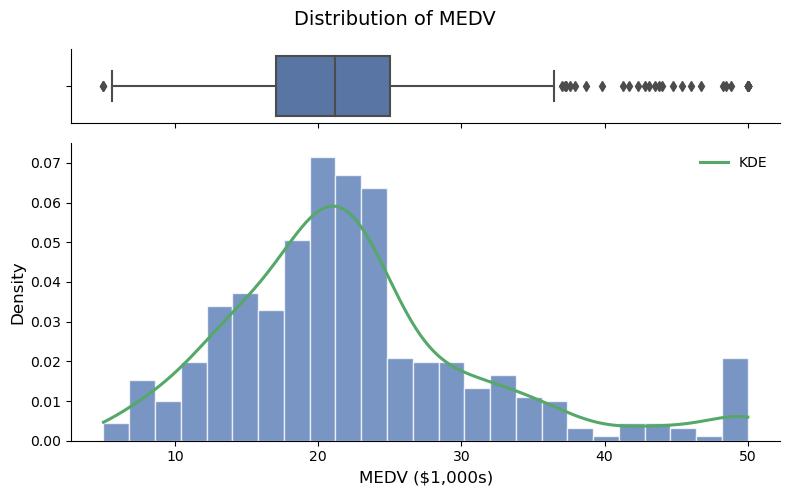

Observations at MEDV = 50.0: 16


In [7]:
fig, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    gridspec_kw={"height_ratios": (0.2, 0.8)},
    figsize=(8, 5)
)

# Boxplot
sns.boxplot(
    x=df["MEDV"],
    ax=ax_box,
    color=portfolio_palette[0]
)
ax_box.set(xlabel="")

# Histogram
medv_values = df["MEDV"].dropna().to_numpy()

ax_hist.hist(
    medv_values,
    bins=25,
    density=True,
    alpha=0.75,
    color=portfolio_palette[0],
    edgecolor="white"
)

# KDE curve using SciPy for better portability across Seaborn versions
kde = stats.gaussian_kde(medv_values)
x_grid = np.linspace(medv_values.min(), medv_values.max(), 300)

ax_hist.plot(
    x_grid,
    kde(x_grid),
    color=portfolio_palette[1],
    linewidth=2.2,
    label="KDE"
)

ax_hist.set_xlabel("MEDV ($1,000s)", fontsize=12)
ax_hist.set_ylabel("Density", fontsize=12)
ax_hist.legend(frameon=False)

plt.suptitle(
    "Distribution of MEDV",
    fontsize=14
)

sns.despine()
plt.tight_layout()
plt.show()

print(
    "Observations at MEDV = 50.0:",
    int((df["MEDV"] == 50.0).sum())
)

A visible concentration at the maximum target value is worth noting. In this file, multiple observations are exactly `50.0`, so the upper end of the target distribution should be interpreted cautiously.


### Correlation Analysis

For this project, I use **Pearson correlation** because it measures the strength and direction of a **linear relationship** between two numeric variables, which aligns naturally with a Linear Regression baseline.

Important reminder:

> Correlation is useful for exploration, but it does not prove causation and it is not the same thing as feature importance in a multivariable model.


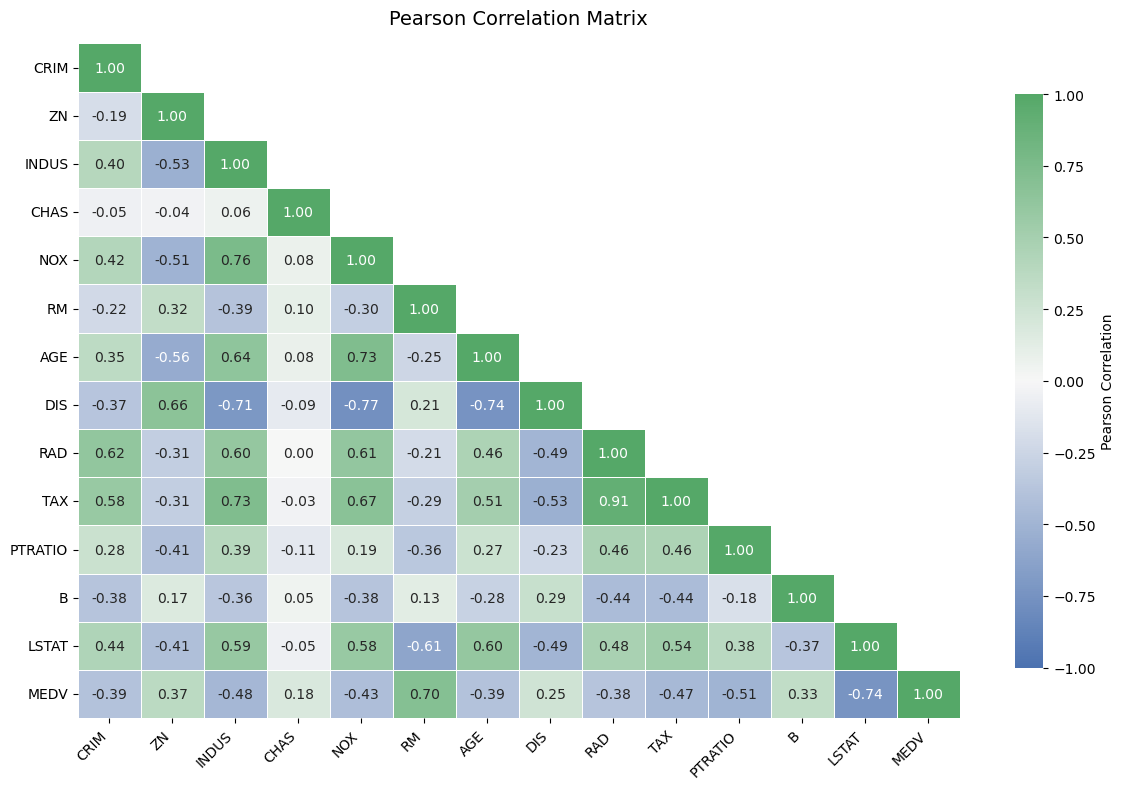

,correlation_with_MEDV
LSTAT,-0.735822
RM,0.695360
PTRATIO,-0.507787
INDUS,-0.481772
TAX,-0.468536
NOX,-0.427321
AGE,-0.394656
CRIM,-0.391363
RAD,-0.381626
ZN,0.373136


In [8]:
target = "MEDV"
df_ordered = pd.concat(
    [df.drop(columns=target), df[target]],
    axis=1
)

# Pearson correlation is used because this project focuses on linear relationships.
corr_matrix = df_ordered.corr(method="pearson")

# Mask the upper triangle to reduce visual clutter.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 8), dpi=100)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=corr_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=False,
    cbar_kws={"shrink": 0.85, "label": "Pearson Correlation"}
)

plt.title(
    "Pearson Correlation Matrix",
    fontsize=14,

    pad=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

target_corr = (
    corr_matrix["MEDV"]
    .drop("MEDV")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_MEDV")
)

target_corr

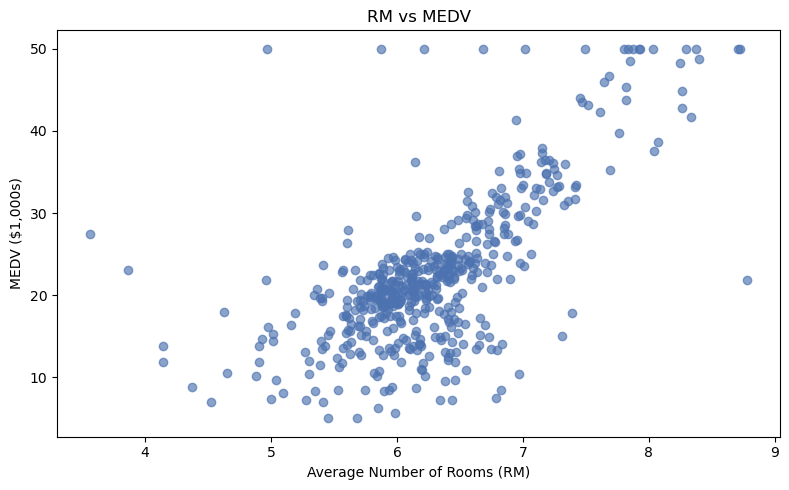

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["RM"], df["MEDV"], alpha=0.65, color=portfolio_palette[0])
plt.title("RM vs MEDV")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("MEDV ($1,000s)")
plt.tight_layout()
plt.show()

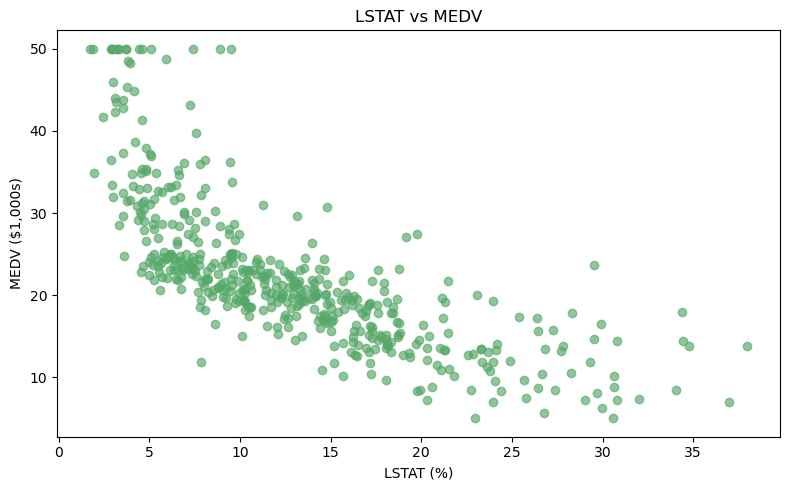

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["LSTAT"], df["MEDV"], alpha=0.65, color=portfolio_palette[1])
plt.title("LSTAT vs MEDV")
plt.xlabel("LSTAT (%)")
plt.ylabel("MEDV ($1,000s)")
plt.tight_layout()
plt.show()

### Outlier Review

I use the IQR rule below to **flag** unusually distant values, but I do not automatically remove or cap them.

Why?

An outlier is not automatically a bad data point. In a real project, I would first investigate whether it is:

- a data-entry error,
- a measurement issue,
- or a valid but rare observation.

Blindly clipping every outlier can remove meaningful information and distort the original relationships.


In [11]:
def iqr_outlier_count(series):
    values = series.dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((values < lower) | (values > upper)).sum()
    return int(count)

outlier_counts = pd.Series(
    {col: iqr_outlier_count(df[col]) for col in df.columns},
    name="iqr_outlier_count"
).sort_values(ascending=False)

outlier_counts.to_frame()

,iqr_outlier_count
B,77
CRIM,65
ZN,63
MEDV,40
CHAS,34
RM,30
PTRATIO,15
LSTAT,7
DIS,5
INDUS,0


## 8. Statistical Analysis

### Mean, Median, Variance, and Standard Deviation

These descriptive statistics help summarize the center and spread of each variable. They are especially useful when deciding whether a feature is skewed or contains extreme values.

### Correlation

For this dataset, `LSTAT` has one of the strongest negative linear relationships with `MEDV`, while `RM` has one of the strongest positive relationships.

### Multicollinearity

Linear Regression coefficients can become unstable when predictors are strongly related to one another. To inspect this, I calculate the **Variance Inflation Factor (VIF)** on the training data.

A high VIF does not automatically mean a feature must be removed, but it is a signal that coefficient interpretation may require caution.


## 9. Train / Test Split

I separate the target from the predictors and reserve **20%** of the data for final testing.

The split happens **before** fitting the imputer. This is important because preprocessing steps should learn their parameters only from the training data.


In [12]:
X = df.drop(columns="MEDV")
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (404, 13)
Test set: (102, 13)


## 10. Data Preprocessing

The predictors contain missing values, so the model needs an imputation strategy.

I use **median imputation** because it is simple and relatively robust to extreme values compared with mean imputation.

Most importantly, imputation is placed inside a scikit-learn `Pipeline`:

`Training data → Median Imputer → Linear Regression`

The same fitted preprocessing is then applied automatically to the test data and future observations.

### Why no StandardScaler here?

Ordinary least-squares Linear Regression does not require feature scaling to produce valid predictions. Keeping the features in their original units also makes the raw coefficients easier to interpret.

Scaling becomes much more important when we move to methods such as **Ridge, Lasso, Elastic Net, KNN, SVM, or PCA**.


In [13]:
model_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression())
    ]
)

model_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', LinearRegression())])

## 11. Linear Regression — Short Tutorial

Linear Regression models the target as a weighted combination of the input features:

\[
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
\]

Where:

- `ŷ` is the predicted target,
- `β₀` is the **intercept**,
- each `βᵢ` is a **coefficient**,
- and each `xᵢ` is a feature.

### What does the model optimize?

Ordinary Least Squares (OLS) chooses the coefficients that minimize the **sum of squared residuals**.

A residual is:

\[
e_i = y_i - \hat{y}_i
\]

### Key assumptions to check

For classical linear-model inference, we care about:

1. **Linearity** — the relationship is reasonably linear.
2. **Independence** — observations/errors are independent.
3. **Homoscedasticity** — residual variance is reasonably constant.
4. **Residual normality** — especially relevant for classical confidence intervals and hypothesis tests.
5. **Limited multicollinearity** — predictors should not be near-duplicates of one another.

A useful distinction:

> The target variable itself does **not** have to be normally distributed. Residual behavior is what matters for the usual normal-error assumptions.


## 12. Multicollinearity Check with VIF

VIF for a predictor is:

\[
VIF_j = \frac{1}{1 - R_j^2}
\]

where `R²ⱼ` comes from predicting that feature using all the other predictors.

I calculate VIF using **only the training set** after median imputation.


In [14]:
train_imputer = SimpleImputer(strategy="median")
X_train_imputed = train_imputer.fit_transform(X_train)

vif_rows = []

for idx, feature in enumerate(X.columns):
    target_feature = X_train_imputed[:, idx]
    other_features = np.delete(X_train_imputed, idx, axis=1)

    auxiliary_model = LinearRegression()
    auxiliary_model.fit(other_features, target_feature)
    auxiliary_r2 = auxiliary_model.score(other_features, target_feature)

    vif = np.inf if auxiliary_r2 >= 1 else 1 / (1 - auxiliary_r2)
    vif_rows.append((feature, vif))

vif_table = (
    pd.DataFrame(vif_rows, columns=["feature", "VIF"])
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_table

,feature,VIF
0,TAX,8.792584
1,RAD,7.521102
2,NOX,4.225809
3,DIS,4.109414
4,INDUS,3.373062
5,AGE,2.732621
6,LSTAT,2.554063
7,ZN,2.268418
8,RM,1.870094
9,PTRATIO,1.818583


The VIF table is a diagnostic, not an automatic feature-removal rule. For example, `TAX` and `RAD` show relatively high multicollinearity in this training split, which means their individual coefficients should be interpreted carefully.


## 13. Model Training

The pipeline is fitted only on the training data.


In [15]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## 14. Evaluation Metrics

I use multiple regression metrics because each one answers a different question.

### MAE — Mean Absolute Error

Average absolute prediction error.

- Easy to interpret
- Same unit as the target
- Lower is better

### MSE — Mean Squared Error

Squares each error before averaging.

- Penalizes large errors more heavily
- Lower is better

### RMSE — Root Mean Squared Error

Square root of MSE.

- Same unit as the target
- More sensitive to large errors than MAE
- Lower is better

### R² — Coefficient of Determination

Measures how much of the variation in the target is explained by the model relative to predicting the mean.

- Higher is generally better
- `1.0` is a perfect fit
- It can be negative on unseen data

### Adjusted R²

Adjusted R² penalizes the use of unnecessary predictors and is useful when comparing linear models with different numbers of features.


In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics_table = pd.DataFrame(
    {
        "Metric": ["MAE", "MSE", "RMSE", "R²", "Adjusted R²"],
        "Value": [mae, mse, rmse, r2, adjusted_r2]
    }
)

metrics_table

,Metric,Value
0,MAE,3.147609
1,MSE,24.983445
2,RMSE,4.998344
3,R²,0.659319
4,Adjusted R²,0.608991


## 15. Actual vs Predicted Values

A good regression model should place predicted values reasonably close to the 45-degree reference line.


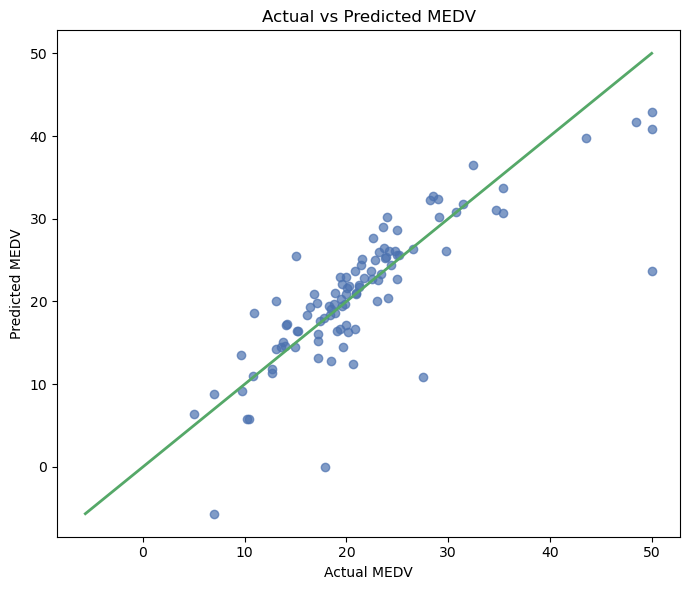

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color=portfolio_palette[0])

reference_min = min(y_test.min(), y_pred.min())
reference_max = max(y_test.max(), y_pred.max())

plt.plot(
    [reference_min, reference_max],
    [reference_min, reference_max],
    color=portfolio_palette[1],
    linewidth=2
)

plt.title("Actual vs Predicted MEDV")
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.tight_layout()
plt.show()

## 16. Residual Analysis

Residuals help us check whether the model is missing systematic structure.

I inspect:

- residuals vs fitted values,
- residual distribution,
- and a Q-Q plot for approximate normality.

We are looking for **patterns**, not perfection.


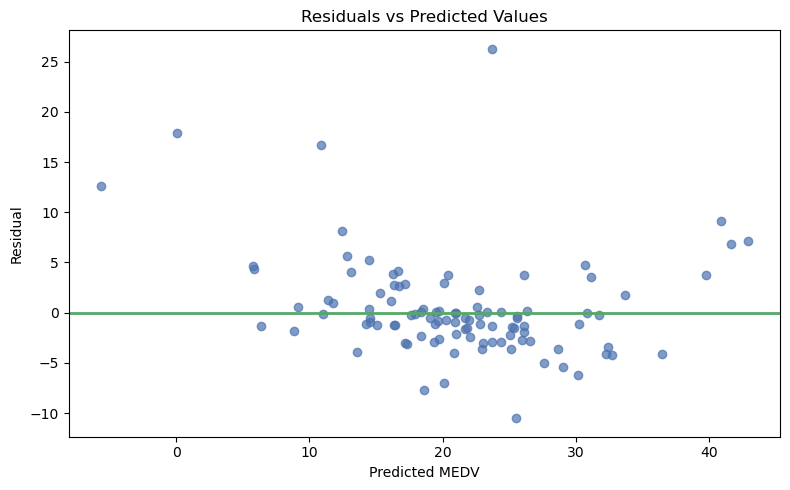

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7, color=portfolio_palette[0])
plt.axhline(0, color=portfolio_palette[1], linewidth=2)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted MEDV")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

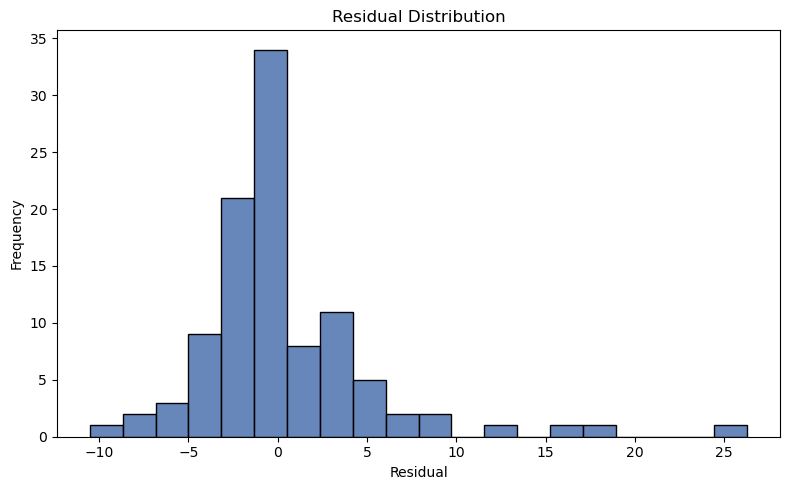

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, color=portfolio_palette[0], alpha=0.85)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

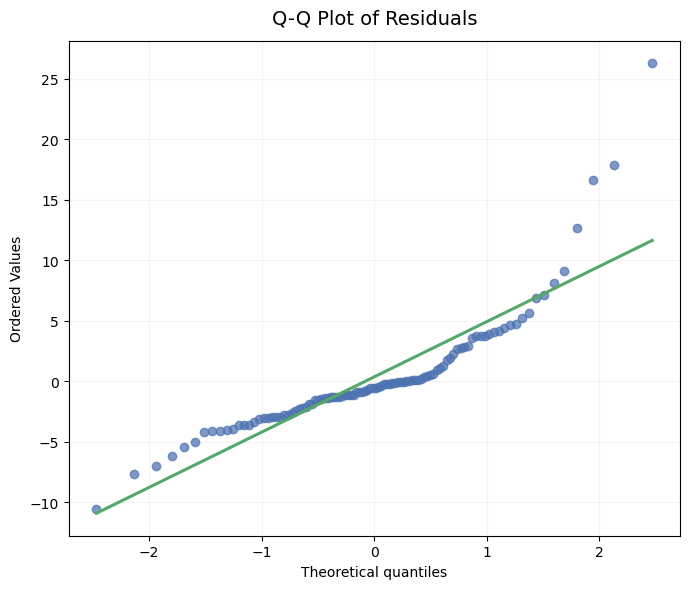

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=ax
)

# Q-Q plot sample points
qq_points = ax.get_lines()[0]
qq_points.set_markerfacecolor(portfolio_palette[0])
qq_points.set_markeredgecolor(portfolio_palette[0])
qq_points.set_alpha(0.72)
qq_points.set_markersize(6)

# Fitted reference line
qq_line = ax.get_lines()[1]
qq_line.set_color(portfolio_palette[1])
qq_line.set_linewidth(2.2)

ax.set_title(
    "Q-Q Plot of Residuals",
    fontsize=14,
    pad=12
)

ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### Residual interpretation

The residual diagnostics show that the linear model is a useful baseline, but the errors are not perfectly well-behaved across the full range of predictions.

That is a practical sign that:

- some relationships may be nonlinear,
- interactions may matter,
- and a simple linear model may not capture all structure in the dataset.

This is one reason I treat Linear Regression as the **baseline**, not the final word.


## 17. Model Coefficients

A coefficient represents the expected change in predicted `MEDV` associated with a one-unit increase in that feature, **holding the other predictors constant**.

However, the features have very different units, so coefficient magnitudes should **not** be compared directly as if they were feature-importance scores.


In [21]:
linear_model = model_pipeline.named_steps["model"]

coefficient_table = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": linear_model.coef_
    }
).sort_values("Coefficient")

print("Intercept:", linear_model.intercept_)
coefficient_table

Intercept: 28.244251041076478


,Feature,Coefficient
4,NOX,-15.983756
7,DIS,-1.507228
10,PTRATIO,-0.890880
12,LSTAT,-0.444862
0,CRIM,-0.112661
2,INDUS,-0.025775
6,AGE,-0.018087
9,TAX,-0.009048
11,B,0.011984
1,ZN,0.028315


## 18. Cross-Validation

A single train/test split can give a result that depends on which observations happened to enter the test set.

To get a more stable estimate, I use **5-fold cross-validation** with shuffling.

Because the imputer is inside the pipeline, each fold learns its missing-value replacement values only from that fold's training portion.


In [22]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_pipeline,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error"
    }
)

cv_summary = pd.DataFrame(
    {
        "Fold": np.arange(1, 6),
        "R²": cv_results["test_r2"],
        "MAE": -cv_results["test_mae"],
        "RMSE": np.sqrt(-cv_results["test_mse"])
    }
)

display(cv_summary)

print("\nCross-validation mean:")
print(f"R²:   {cv_summary['R²'].mean():.3f}")
print(f"MAE:  {cv_summary['MAE'].mean():.3f}")
print(f"RMSE: {cv_summary['RMSE'].mean():.3f}")

,Fold,R²,MAE,RMSE
0,1,0.659319,3.147609,4.998344
1,2,0.742835,3.399329,4.493790
2,3,0.696654,3.476331,5.253375
3,4,0.758545,3.823015,5.021878
4,5,0.680428,3.230719,4.793671



Cross-validation mean:
R²:   0.708
MAE:  3.415
RMSE: 4.912


## 19. Example Prediction

For a realistic demonstration, I take one observation from the held-out test set and pass the raw feature values directly to the fitted pipeline.

There is no manual scaling or hand-written coefficient calculation. The pipeline applies the same preprocessing used during training.


In [23]:
example_index = X_test.index[0]
example_features = X_test.loc[[example_index]]
example_actual = y_test.loc[example_index]
example_prediction = model_pipeline.predict(example_features)[0]

display(example_features)

print(f"Actual MEDV:    {example_actual:.2f}")
print(f"Predicted MEDV: {example_prediction:.2f}")
print(f"Absolute error: {abs(example_actual - example_prediction):.2f}")

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,NaN,0.0,0.51,6.416,NaN,2.6463,5,296,16.6,395.5,9.04


Actual MEDV:    23.60
Predicted MEDV: 29.04
Absolute error: 5.44


## 20. Results

With an 80/20 split and `random_state=42`, this baseline Linear Regression pipeline achieves approximately:

- **MAE:** 3.15
- **RMSE:** 5.00
- **R²:** 0.659
- **Adjusted R²:** 0.609

Because `MEDV` is measured in **thousands of dollars**, an RMSE of about `5.00` corresponds to roughly **$5,000** in the dataset's original target units.

Across 5 shuffled folds, the model reaches an average:

- **R²:** about 0.708
- **MAE:** about 3.42
- **RMSE:** about 4.92

These results suggest that Linear Regression captures a meaningful part of the signal, but there is still substantial unexplained variation.


## 21. Conclusion

This project shows why a clean machine-learning workflow matters as much as calling `fit()` and `predict()`.

The final baseline:

- detects missing values before modeling,
- avoids filling the full dataset before the split,
- keeps preprocessing inside a pipeline,
- avoids unnecessary target transformation,
- does not blindly cap outliers,
- evaluates the model with several regression metrics,
- checks residual behavior and multicollinearity,
- and uses cross-validation to reduce dependence on one split.

Two predictors stand out during EDA:

- `RM` has a strong positive relationship with `MEDV`.
- `LSTAT` has a strong negative relationship with `MEDV`.

At the same time, the residual diagnostics and test error show that the problem is not perfectly linear. That makes this model a useful and interpretable **baseline**, while leaving clear room for improvement.


## 22. Future Improvements

Good next steps would be:

1. Compare the baseline with **Ridge, Lasso, and Elastic Net**.
2. Test **Polynomial Features** to capture nonlinear relationships.
3. Compare with tree-based models such as Random Forest or Gradient Boosting.
4. Investigate the target ceiling at `MEDV = 50`.
5. Study influential observations using leverage / Cook's distance.
6. Use nested or repeated cross-validation for more robust model comparison.
7. Revisit feature inclusion from an ethical and modern-use perspective rather than treating the historical feature set as automatically appropriate.


## 23. Technologies & Libraries

- Python
- NumPy
- pandas
- Matplotlib
- SciPy
- scikit-learn
- Jupyter Notebook

### Core ML concepts used

- Supervised Learning
- Regression
- Train/Test Split
- Missing-Value Imputation
- Pipeline
- Ordinary Least Squares
- MAE / MSE / RMSE / R² / Adjusted R²
- Residual Analysis
- Correlation
- Multicollinearity / VIF
- K-Fold Cross-Validation
- Data Leakage Prevention


## 24. GitHub ↔ Kaggle

### GitHub Repository
[View the full project on GitHub](https://github.com/Anahita-Pouladi/boston-housing-linear-regression)

### Kaggle Notebook
[Run the notebook on Kaggle](https://www.kaggle.com/code/anahitapouladi/boston-housing-price-prediction-linear-regressio)

The GitHub version should remain the fully documented project, while the Kaggle version can focus on a clean, executable notebook experience.


---

## What I Learned

The most important lesson from this project is that a regression workflow is not just:

```python
model.fit(X_train, y_train)
model.predict(X_test)
```

A reliable project also requires decisions about data quality, leakage, preprocessing, metrics, assumptions, diagnostics, and interpretation.

That reasoning is what turns a notebook into a portfolio project.
